In [367]:
#importing necessary packages
from collections import defaultdict
import gzip
from Bio.Align import PairwiseAligner
import numpy as np
#import matplotlib.pyplot as plt
import Bio.Seq
import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns
import Bio.Seq
import Bio.SeqIO
from Bio.SeqRecord import SeqRecord
import os
import sys
from pathlib import Path
#package for hamming distance 
import Levenshtein as lv
plt.rc('font', family='Helvetica')


In [177]:
#-----GLOBAL VARIABLES------
MIN_QUALITY = 30 #originally set to 30
GZ=True

#THIS FUNCTION MAY NEED TO BE UPDATED DEPENDING ON HOW THE DATA IS STRUCTURED
def fastq_reader(fname, gz=False):
    _open = gzip.open if gz else open
    proc_read = (lambda line: line.strip().decode()) if gz else (lambda line: line.strip())
    proc_qual = (lambda line: line.strip()) if gz else (lambda line: line.strip().encode('utf-8'))
    with _open(fname, 'r') as f:
        for i, line in enumerate(f):
            if i % 4 == 0:
                identifier = proc_read(line)
            elif i % 4 == 1:
                read = proc_read(line)
            elif i % 4 == 3:
                quality = proc_qual(line)
                yield identifier[-20:], read, quality #protospacer (index2), read, quality score



In [ ]:
CDK1 = '../../source_data/03_NGS_library_validation/30-1071435623/00_fastq/CDK1_join.fastq.gz'
CDK2 = '../../source_data/03_NGS_library_validation/30-1071435623/00_fastq/CDK2_join.fastq.gz'
CDK3 = '../../source_data/03_NGS_library_validation/30-1071435623/00_fastq/CDK3_join.fastq.gz'

PCR1_F = 'CGCTCTTCCGATCTCTAGCGTTCGAGTTAGGAATT'
PCR1_R = 'CTGAACCGCTCTTCCGATCTTTGTGGAAAGGACGAAACACC'

#PCR1_F = 'kajhdsf'

#PCR1_F = 'CGCTCTTCCGATCTCTAGCGTTCGAGTTAGGAATT'
#PCR1_R = 'CTGAACCGCTCTTCCGATCTTTGTGGAAAGGACGAAACACC'

In [251]:

def proto_bc_extractor(CDK1, breakpoint=False):
    proto = []
    bc = []

    PCR1_F_rc = str(Bio.Seq.Seq(PCR1_F[-20:]).reverse_complement())

    for i, ((proto1, r1, q1)) in enumerate(fastq_reader(CDK1, gz=GZ), 1):
        #print(len(r1))
        #print(r1)

        #forward orientation read
        good_read = False

        if (PCR1_R[-25:] in r1):
            good_read = True
            r1 = r1

        elif (PCR1_F[-25:] in r1):
            r1 = str(Bio.Seq.Seq(r1).reverse_complement())

            if (PCR1_R[-25:] in r1):
                good_read = True

        
        if good_read == True:

            loc = r1.find(PCR1_R[-25:]) #+ 25
            assert r1[loc:loc+25]==PCR1_R[-25:]
            
            proto.append(r1[loc+25:loc+25+20])
            #print(r1[loc+25:loc+25+20])

            #and then find the barcode
            if PCR1_F_rc in r1:
                loc2 = r1.find(PCR1_F_rc) - 1
                bc.append(r1[loc2-13:loc2])

            else:
                bc.append('None')


        if breakpoint!=False:
            if i>breakpoint:
                break
            #print('yes')

    df = pd.DataFrame(dict(zip(['protospacer', 'BC'], [proto, bc])))

    return df


def proto_bc_counter(df, library):

    df['BC_id'] = 'None'
    df['proto_id'] = 'None'
    df['BC_proto_match'] = False
    df['proto_multiple'] = False

    for i, val in df.iterrows():

        p = val['protospacer']
        bc = val['BC']

        #first barcode
        j = library.loc[library['Hamming_BC'] == bc, 'gRNA_id']

        if len(j)==0:
            continue

        elif len(j)==1:
            df.loc[i, 'BC_id'] = j.values[0]


        #then protospacer

        j2 = library.loc[library['proto_G+19']==p, 'gRNA_id']
        if len(j2)==0:
            continue
    
        elif len(j2)==1:
            df.loc[i, 'proto_id'] = j2.values[0]

        elif len(j2)>1:
            if j.values[0] in list(j2):
                df.loc[i, 'proto_id'] = j.values[0]
            else:
                df.loc[i, 'proto_id'] = j2.values[0]
                df.loc[i, 'proto_multiple'] = True

    for i, val in df.iterrows():
        if val['BC_id']==val['proto_id']:
            df.loc[i, 'BC_proto_match'] = True


    return df

    

In [252]:
library = pd.read_csv('CDK_library_final.csv')

library2 = library[['gRNA_id', 'proto_G+19', 'Pool', 'classification']]
library2['Count_proto_CDK1'] = 0
library2['Count_proto_CDK2'] = 0
library2['Count_proto_CDK3'] = 0

library2['Count_BC_CDK1'] = 0
library2['Count_BC_CDK2'] = 0
library2['Count_BC_CDK3'] = 0

cdk1 = proto_bc_extractor(CDK1)
cdk2 = proto_bc_extractor(CDK2)
cdk3 = proto_bc_extractor(CDK3)

cdk1_df = proto_bc_counter(cdk1, library)
cdk2_df = proto_bc_counter(cdk2, library)
cdk3_df = proto_bc_counter(cdk3, library)

for i, val in cdk1_df.iterrows():
    library2.loc[library2['gRNA_id']==val['BC_id'], 'Count_BC_CDK1']+=1
    library2.loc[library2['gRNA_id']==val['proto_id'], 'Count_proto_CDK1']+=1

for i, val in cdk2_df.iterrows():
    library2.loc[library2['gRNA_id']==val['BC_id'], 'Count_BC_CDK2']+=1
    library2.loc[library2['gRNA_id']==val['proto_id'], 'Count_proto_CDK2']+=1

for i, val in cdk3_df.iterrows():
    library2.loc[library2['gRNA_id']==val['BC_id'], 'Count_BC_CDK3']+=1
    library2.loc[library2['gRNA_id']==val['proto_id'], 'Count_proto_CDK3']+=1

/var/folders/5g/xxjcy2g531n02hnyb6d8qdsr0000gn/T/ipykernel_77518/1830116094.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  library2['Count_proto_CDK1'] = 0
/var/folders/5g/xxjcy2g531n02hnyb6d8qdsr0000gn/T/ipykernel_77518/1830116094.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  library2['Count_proto_CDK2'] = 0
/var/folders/5g/xxjcy2g531n02hnyb6d8qdsr0000gn/T/ipykernel_77518/1830116094.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [257]:
#save to NGS_library_validation folder

#cdk1_df.to_csv('NGS_library_validation/CDK1_reads.csv', index=False)
#cdk2_df.to_csv('NGS_library_validation/CDK2_reads.csv', index=False)
#cdk3_df.to_csv('NGS_library_validation/CDK3_reads.csv', index=False)
#library2.to_csv('NGS_library_validation/combined_counts.csv', index=False)

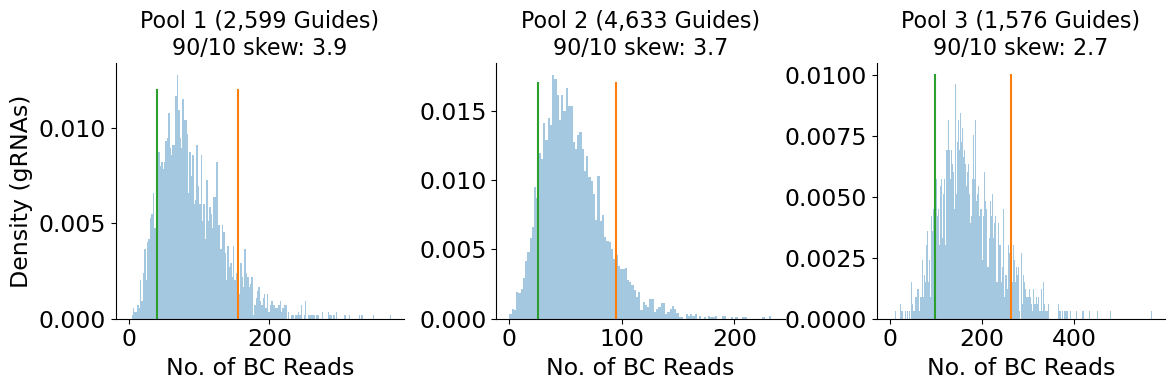

In [305]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(12,4))

bins1 = np.linspace(0,373,374//2)
bins2 = np.linspace(0,233,234//2)
bins3 = np.linspace(0,569,570//2)
ax[0].hist(library2[library2['Pool']=='F1-R1']['Count_BC_CDK1'], bins=bins1, label='Pool 1', density=True, alpha=.4)
ax[1].hist(library2[library2['Pool']=='F2-R2']['Count_BC_CDK2'], bins=bins2, label='Pool 2', density=True, alpha=.4)
ax[2].hist(library2[library2['Pool']=='F3-R3']['Count_BC_CDK3'], bins=bins3, label='Pool 3', density=True, alpha=.4)

s_list1 = sorted(list(library2[library2['Pool']=='F1-R1']['Count_BC_CDK1']))
s_list2 = sorted(list(library2[library2['Pool']=='F2-R2']['Count_BC_CDK2']))
s_list3 = sorted(list(library2[library2['Pool']=='F3-R3']['Count_BC_CDK3']))

pool1_skew = s_list1[int(len(s_list1)*.9)]/s_list1[int(len(s_list1)*.1)]
pool2_skew = s_list2[int(len(s_list2)*.9)]/s_list2[int(len(s_list2)*.1)]
pool3_skew = s_list3[int(len(s_list3)*.9)]/s_list3[int(len(s_list3)*.1)]

ax[0].plot([s_list1[int(len(s_list1)*.9)], s_list1[int(len(s_list1)*.9)]], [0, .012])
ax[0].plot([s_list1[int(len(s_list1)*.1)], s_list1[int(len(s_list1)*.1)]], [0, .012])
ax[1].plot([s_list2[int(len(s_list2)*.9)], s_list2[int(len(s_list2)*.9)]], [0, .017])
ax[1].plot([s_list2[int(len(s_list2)*.1)], s_list2[int(len(s_list2)*.1)]], [0, .017])
ax[2].plot([s_list3[int(len(s_list3)*.9)], s_list3[int(len(s_list3)*.9)]], [0, .01])
ax[2].plot([s_list3[int(len(s_list3)*.1)], s_list3[int(len(s_list3)*.1)]], [0, .01])
#ax.hist(library2[library2['Pool']=='F1-R1']['Count_CDK2'], bins=np.linspace(0,200,200), label='pool 1', density=True)
ax[0].tick_params(axis='both', which='major', labelsize=17)
ax[1].tick_params(axis='both', which='major', labelsize=17)
ax[2].tick_params(axis='both', which='major', labelsize=17)


ax[0].set_ylabel('Density (gRNAs)', fontsize=17)
ax[0].set_xlabel('No. of BC Reads', fontsize=17)
ax[1].set_xlabel('No. of BC Reads', fontsize=17)
ax[2].set_xlabel('No. of BC Reads', fontsize=17)
ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[2].spines[['right', 'top']].set_visible(False)

ax[0].set_title(f'Pool 1 (2,599 Guides)\n90/10 skew: {np.round(pool1_skew, 1)}', fontsize=16)
ax[1].set_title(f'Pool 2 (4,633 Guides)\n90/10 skew: {np.round(pool2_skew, 1)}', fontsize=16)
ax[2].set_title(f'Pool 3 (1,576 Guides)\n90/10 skew: {np.round(pool3_skew, 1)}', fontsize=16)


#ax[0].legend(fontsize=15, loc='upper right')
#ax.set_ylim(0,100)
#ax.set_yticks([0,10,20,30,40,50,60,70,80,90,100]);
#ax.grid(axis='y', linestyle='dashed', alpha=.5)

fig.tight_layout()

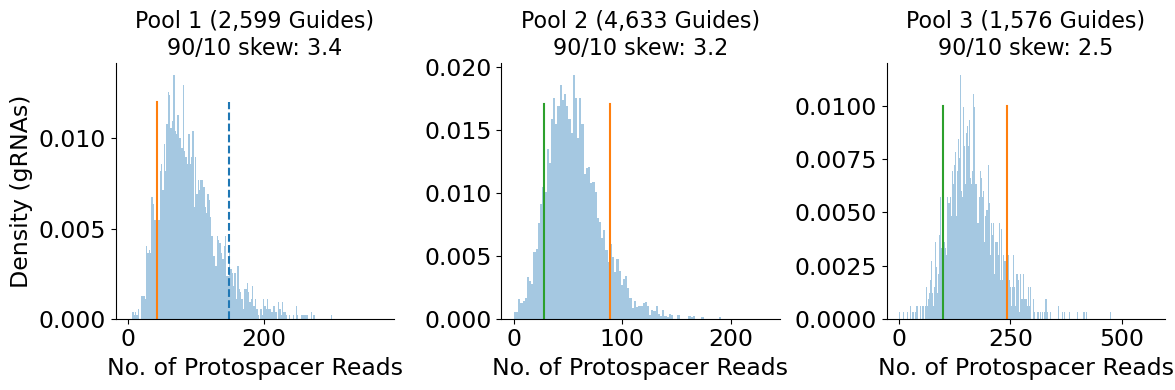

In [307]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(12,4))

bins1 = np.linspace(0,373,374//2)
bins2 = np.linspace(0,233,234//2)
bins3 = np.linspace(0,569,570//2)
ax[0].hist(library2[library2['Pool']=='F1-R1']['Count_proto_CDK1'], bins=bins1, label='Pool 1', density=True, alpha=.4)
ax[1].hist(library2[library2['Pool']=='F2-R2']['Count_proto_CDK2'], bins=bins2, label='Pool 2', density=True, alpha=.4)
ax[2].hist(library2[library2['Pool']=='F3-R3']['Count_proto_CDK3'], bins=bins3, label='Pool 3', density=True, alpha=.4)

s_list1 = sorted(list(library2[library2['Pool']=='F1-R1']['Count_proto_CDK1']))
s_list2 = sorted(list(library2[library2['Pool']=='F2-R2']['Count_proto_CDK2']))
s_list3 = sorted(list(library2[library2['Pool']=='F3-R3']['Count_proto_CDK3']))

pool1_skew = s_list1[int(len(s_list1)*.9)]/s_list1[int(len(s_list1)*.1)]
pool2_skew = s_list2[int(len(s_list2)*.9)]/s_list2[int(len(s_list2)*.1)]
pool3_skew = s_list3[int(len(s_list3)*.9)]/s_list3[int(len(s_list3)*.1)]

ax[0].plot([s_list1[int(len(s_list1)*.9)], s_list1[int(len(s_list1)*.9)]], [0, .012], linestyle='dashed', color='tab:blue')
ax[0].plot([s_list1[int(len(s_list1)*.1)], s_list1[int(len(s_list1)*.1)]], [0, .012])
ax[1].plot([s_list2[int(len(s_list2)*.9)], s_list2[int(len(s_list2)*.9)]], [0, .017])
ax[1].plot([s_list2[int(len(s_list2)*.1)], s_list2[int(len(s_list2)*.1)]], [0, .017])
ax[2].plot([s_list3[int(len(s_list3)*.9)], s_list3[int(len(s_list3)*.9)]], [0, .01])
ax[2].plot([s_list3[int(len(s_list3)*.1)], s_list3[int(len(s_list3)*.1)]], [0, .01])

#ax.hist(library2[library2['Pool']=='F1-R1']['Count_CDK2'], bins=np.linspace(0,200,200), label='pool 1', density=True)
ax[0].tick_params(axis='both', which='major', labelsize=17)
ax[1].tick_params(axis='both', which='major', labelsize=17)
ax[2].tick_params(axis='both', which='major', labelsize=17)


ax[0].set_ylabel('Density (gRNAs)', fontsize=17)
ax[0].set_xlabel('No. of Protospacer Reads', fontsize=17)
ax[1].set_xlabel('No. of Protospacer Reads', fontsize=17)
ax[2].set_xlabel('No. of Protospacer Reads', fontsize=17)
ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[2].spines[['right', 'top']].set_visible(False)

ax[0].set_title(f'Pool 1 (2,599 Guides)\n90/10 skew: {np.round(pool1_skew, 1)}', fontsize=16)
ax[1].set_title(f'Pool 2 (4,633 Guides)\n90/10 skew: {np.round(pool2_skew, 1)}', fontsize=16)
ax[2].set_title(f'Pool 3 (1,576 Guides)\n90/10 skew: {np.round(pool3_skew, 1)}', fontsize=16)


#ax[0].legend(fontsize=15, loc='upper right')
#ax.set_ylim(0,100)
#ax.set_yticks([0,10,20,30,40,50,60,70,80,90,100]);
#ax.grid(axis='y', linestyle='dashed', alpha=.5)

fig.tight_layout()

In [309]:
sum(library2[library2['Pool']=='F1-R1']['Count_BC_CDK1'])

252179

In [340]:
sum(pool3)/(len_pool3_100x)

1.8822883553593404

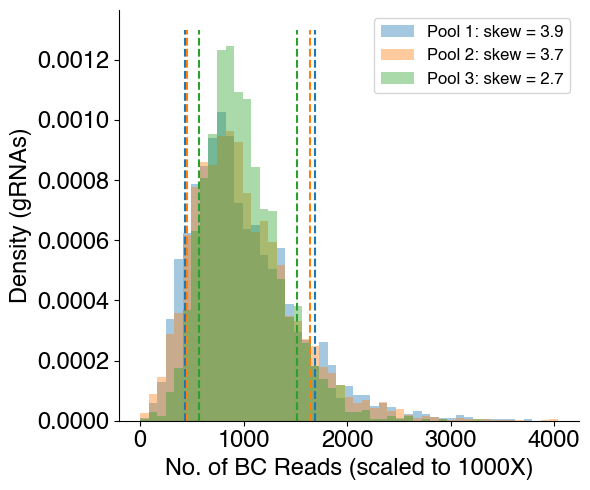

In [375]:
total_counts_pool1 = sum(library2[library2['Pool']=='F1-R1']['Count_BC_CDK1'])
len_pool1_100x = len(library2[library2['Pool']=='F1-R1'])*1000

total_counts_pool2 = sum(library2[library2['Pool']=='F2-R2']['Count_BC_CDK2'])
len_pool2_100x = len(library2[library2['Pool']=='F2-R2'])*1000

total_counts_pool3 = sum(library2[library2['Pool']=='F3-R3']['Count_BC_CDK3'])
len_pool3_100x = len(library2[library2['Pool']=='F3-R3'])*1000

pool1 = ((len_pool1_100x/total_counts_pool1)*np.asarray(library2[library2['Pool']=='F1-R1']['Count_BC_CDK1']))
pool2 = ((len_pool2_100x/total_counts_pool2)*np.asarray(library2[library2['Pool']=='F2-R2']['Count_BC_CDK2']))
pool3 = ((len_pool3_100x/total_counts_pool3)*np.asarray(library2[library2['Pool']=='F3-R3']['Count_BC_CDK3']))


fig, ax = plt.subplots(1,1, figsize=(6,5))



s_list1 = sorted(pool1)
s_list2 = sorted(pool2)
s_list3 = sorted(pool3)

pool1_skew = np.round(s_list1[int(len(s_list1)*.9)]/s_list1[int(len(s_list1)*.1)], 1)
pool2_skew = np.round(s_list2[int(len(s_list2)*.9)]/s_list2[int(len(s_list2)*.1)],1)
pool3_skew = np.round(s_list3[int(len(s_list3)*.9)]/s_list3[int(len(s_list3)*.1)],1)

ax.plot([s_list1[int(len(s_list1)*.9)], s_list1[int(len(s_list1)*.9)]], [0, .0013], linestyle='dashed', color='tab:blue')
ax.plot([s_list1[int(len(s_list1)*.1)], s_list1[int(len(s_list1)*.1)]], [0, .0013], linestyle='dashed', color='tab:blue')
ax.plot([s_list2[int(len(s_list2)*.9)], s_list2[int(len(s_list2)*.9)]], [0, .0013], linestyle='dashed', color='tab:orange')
ax.plot([s_list2[int(len(s_list2)*.1)], s_list2[int(len(s_list2)*.1)]], [0, .0013], linestyle='dashed', color='tab:orange')
ax.plot([s_list3[int(len(s_list3)*.9)], s_list3[int(len(s_list3)*.9)]], [0, .0013], linestyle='dashed', color='tab:green')
ax.plot([s_list3[int(len(s_list3)*.1)], s_list3[int(len(s_list3)*.1)]], [0, .0013], linestyle='dashed', color='tab:green')


bins = np.linspace(0, 4037, 50)

ax.hist(pool1, bins=bins, label=f'Pool 1: skew = {pool1_skew}',alpha=.4, density=True)
ax.hist(pool2, bins=bins, label=f'Pool 2: skew = {pool2_skew}',alpha=.4, density=True)
ax.hist(pool3, bins=bins, label=f'Pool 3: skew = {pool3_skew}',alpha=.4, density=True)

ax.tick_params(axis='both', which='major', labelsize=17)


ax.set_ylabel('Density (gRNAs)', fontsize=17)
ax.set_xlabel('No. of BC Reads (scaled to 1000X)', fontsize=17)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(fontsize=12)
fig.tight_layout()



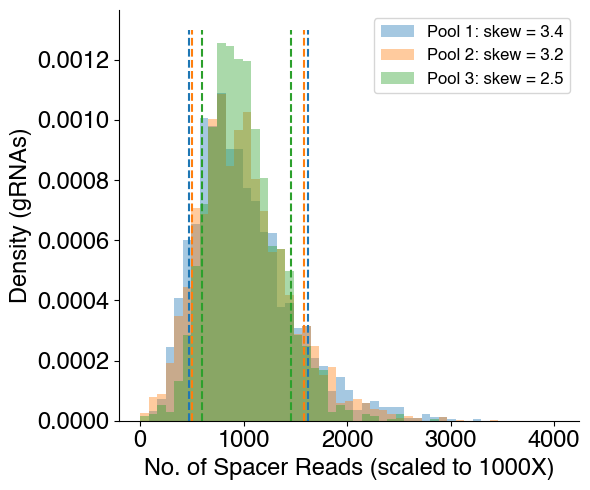

In [376]:
total_counts_pool1 = sum(library2[library2['Pool']=='F1-R1']['Count_proto_CDK1'])
len_pool1_100x = len(library2[library2['Pool']=='F1-R1'])*1000

total_counts_pool2 = sum(library2[library2['Pool']=='F2-R2']['Count_proto_CDK2'])
len_pool2_100x = len(library2[library2['Pool']=='F2-R2'])*1000

total_counts_pool3 = sum(library2[library2['Pool']=='F3-R3']['Count_proto_CDK3'])
len_pool3_100x = len(library2[library2['Pool']=='F3-R3'])*1000

pool1 = ((len_pool1_100x/total_counts_pool1)*np.asarray(library2[library2['Pool']=='F1-R1']['Count_proto_CDK1']))
pool2 = ((len_pool2_100x/total_counts_pool2)*np.asarray(library2[library2['Pool']=='F2-R2']['Count_proto_CDK2']))
pool3 = ((len_pool3_100x/total_counts_pool3)*np.asarray(library2[library2['Pool']=='F3-R3']['Count_proto_CDK3']))


fig, ax = plt.subplots(1,1, figsize=(6,5))



s_list1 = sorted(pool1)
s_list2 = sorted(pool2)
s_list3 = sorted(pool3)

pool1_skew = np.round(s_list1[int(len(s_list1)*.9)]/s_list1[int(len(s_list1)*.1)], 1)
pool2_skew = np.round(s_list2[int(len(s_list2)*.9)]/s_list2[int(len(s_list2)*.1)],1)
pool3_skew = np.round(s_list3[int(len(s_list3)*.9)]/s_list3[int(len(s_list3)*.1)],1)

ax.plot([s_list1[int(len(s_list1)*.9)], s_list1[int(len(s_list1)*.9)]], [0, .0013], linestyle='dashed', color='tab:blue')
ax.plot([s_list1[int(len(s_list1)*.1)], s_list1[int(len(s_list1)*.1)]], [0, .0013], linestyle='dashed', color='tab:blue')
ax.plot([s_list2[int(len(s_list2)*.9)], s_list2[int(len(s_list2)*.9)]], [0, .0013], linestyle='dashed', color='tab:orange')
ax.plot([s_list2[int(len(s_list2)*.1)], s_list2[int(len(s_list2)*.1)]], [0, .0013], linestyle='dashed', color='tab:orange')
ax.plot([s_list3[int(len(s_list3)*.9)], s_list3[int(len(s_list3)*.9)]], [0, .0013], linestyle='dashed', color='tab:green')
ax.plot([s_list3[int(len(s_list3)*.1)], s_list3[int(len(s_list3)*.1)]], [0, .0013], linestyle='dashed', color='tab:green')


bins = np.linspace(0, 4037, 50)

ax.hist(pool1, bins=bins, label=f'Pool 1: skew = {pool1_skew}',alpha=.4, density=True)
ax.hist(pool2, bins=bins, label=f'Pool 2: skew = {pool2_skew}',alpha=.4, density=True)
ax.hist(pool3, bins=bins, label=f'Pool 3: skew = {pool3_skew}',alpha=.4, density=True)

ax.tick_params(axis='both', which='major', labelsize=17)

ax.set_ylabel('Density (gRNAs)', fontsize=17)
ax.set_xlabel('No. of Spacer Reads (scaled to 1000X)', fontsize=17)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(fontsize=12)
fig.tight_layout()

#fig.savefig('NGS_library_validation/proto_rep.pdf')

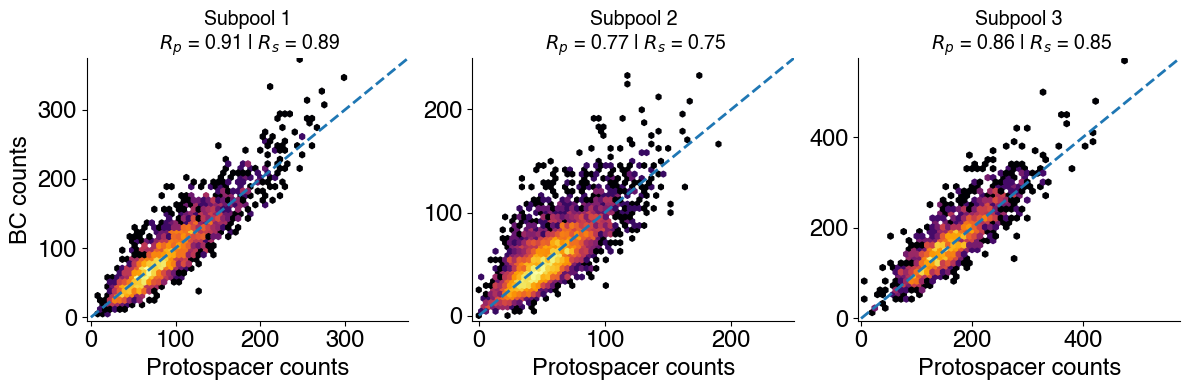

In [413]:
import scipy.stats

proto1 = library2[library2['Pool']=='F1-R1']['Count_proto_CDK1']
bc1 = library2[library2['Pool']=='F1-R1']['Count_BC_CDK1']
proto2 = library2[library2['Pool']=='F2-R2']['Count_proto_CDK2']
bc2 = library2[library2['Pool']=='F2-R2']['Count_BC_CDK2']
proto3 = library2[library2['Pool']=='F3-R3']['Count_proto_CDK3']
bc3 = library2[library2['Pool']=='F3-R3']['Count_BC_CDK3']


fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].hexbin(proto1, bc1, gridsize=50,  cmap='inferno', bins='log') #,yscale="log")
ax[1].hexbin(proto2, bc2, gridsize=50,  cmap='inferno', bins='log') #,yscale="log")
ax[2].hexbin(proto3, bc3, gridsize=50,  cmap='inferno', bins='log') #,yscale="log")

ax[0].set_xlim(-5, 375)
ax[0].set_ylim(-5, 375)
ax[1].set_xlim(-5, 250)
ax[1].set_ylim(-5, 250)
ax[2].set_xlim(-5, 575)
ax[2].set_ylim(-5, 575)

ax[0].plot([0,375], [0, 375], linewidth=2, color='tab:blue', linestyle='dashed')
ax[1].plot([0,250], [0, 250], linewidth=2, color='tab:blue', linestyle='dashed')
ax[2].plot([0,575], [0, 575], linewidth=2, color='tab:blue', linestyle='dashed')

ax[0].tick_params(axis='both', which='major', labelsize=17)
ax[1].tick_params(axis='both', which='major', labelsize=17)
ax[2].tick_params(axis='both', which='major', labelsize=17)

ax[0].set_ylabel('BC counts', fontsize=17)
ax[0].set_xlabel('Protospacer counts', fontsize=17)
ax[1].set_xlabel('Protospacer counts', fontsize=17)
ax[2].set_xlabel('Protospacer counts', fontsize=17)
ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[2].spines[['right', 'top']].set_visible(False)

spear1 = np.round(scipy.stats.spearmanr(proto1, bc1).statistic, 2)
spear2 = np.round(scipy.stats.spearmanr(proto2, bc2).statistic, 2)
spear3 = np.round(scipy.stats.spearmanr(proto3, bc3).statistic, 2)
pear1 = np.round(scipy.stats.pearsonr(proto1, bc1).statistic, 2)
pear2 = np.round(scipy.stats.pearsonr(proto2, bc2).statistic, 2)
pear3 = np.round(scipy.stats.pearsonr(proto3, bc3).statistic, 2)


ax[0].set_title('Subpool 1\n $R_{p}$ = ' + f'{pear1} | ' + '$R_{s}$ = ' + f'{spear1}', fontsize=14)
ax[1].set_title('Subpool 2\n $R_{p}$ = ' + f'{pear2} | ' + '$R_{s}$ = ' + f'{spear2}', fontsize=14)
ax[2].set_title('Subpool 3\n $R_{p}$ = ' + f'{pear3} | ' + '$R_{s}$ = ' + f'{spear3}', fontsize=14)

fig.tight_layout()
#fig.savefig('NGS_library_validation/bc_proto_corr.pdf')

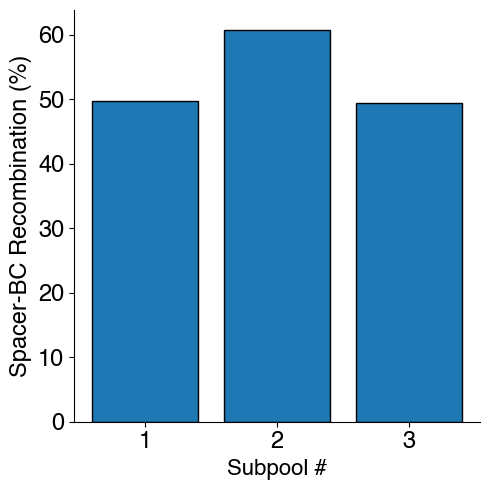

In [425]:
#recombination rate
num1 = cdk1_df[(cdk1_df['BC_id']!='None') & (cdk1_df['proto_id']!='None')]
num2 = cdk2_df[(cdk2_df['BC_id']!='None') & (cdk2_df['proto_id']!='None')]
num3 = cdk3_df[(cdk3_df['BC_id']!='None') & (cdk3_df['proto_id']!='None')]

recomb1 = len(num1[num1['BC_proto_match']==False])/len(num1)
recomb2 = len(num2[num2['BC_proto_match']==False])/len(num2)
recomb3 = len(num3[num3['BC_proto_match']==False])/len(num3)

fig, ax = plt.subplots(figsize=(5,5))
ax.bar([1,2, 3], 100*np.asarray([recomb1, recomb2, recomb3]), linewidth=1, edgecolor='black')
ax.tick_params(axis='both', which='major', labelsize=17)

ax.set_ylabel('Spacer-BC Recombination (%)', fontsize=17)
ax.set_xlabel('Subpool #', fontsize=16)
ax.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('NGS_library_validation/recombination.pdf')

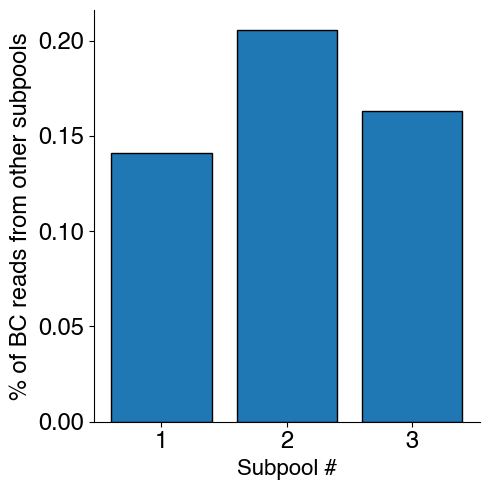

In [437]:
pool1 = library2[library2['Pool']=='F1-R1']
pool2 = library2[library2['Pool']=='F2-R2']
pool3 = library2[library2['Pool']=='F3-R3']

pool1_contam = 100*(sum(pool1['Count_BC_CDK2']) + sum(pool1['Count_BC_CDK3']))/ (sum(pool1['Count_BC_CDK1'])+ sum(pool1['Count_BC_CDK2']) + sum(pool1['Count_BC_CDK3']))
pool2_contam = 100*(sum(pool2['Count_BC_CDK1']) + sum(pool2['Count_BC_CDK3']))/ (sum(pool2['Count_BC_CDK1'])+ sum(pool2['Count_BC_CDK2']) + sum(pool2['Count_BC_CDK3']))
pool3_contam = 100*(sum(pool3['Count_BC_CDK1']) + sum(pool3['Count_BC_CDK2']))/ (sum(pool3['Count_BC_CDK1'])+ sum(pool3['Count_BC_CDK2']) + sum(pool3['Count_BC_CDK3']))

fig, ax = plt.subplots(figsize=(5,5))
ax.bar([1,2, 3], np.asarray([pool1_contam, pool2_contam, pool3_contam]), linewidth=1, edgecolor='black')
ax.tick_params(axis='both', which='major', labelsize=17)

ax.set_ylabel('% of BC reads from other subpools', fontsize=17)
ax.set_xlabel('Subpool #', fontsize=16)
ax.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('NGS_library_validation/contamination.pdf')

In [434]:
sum(pool1['Count_BC_CDK2']) + sum(pool1['Count_BC_CDK3'])

356

In [435]:
(sum(pool1['Count_BC_CDK1'])+ sum(pool1['Count_BC_CDK2']) + sum(pool1['Count_BC_CDK3']))

252535

In [431]:
sum(pool1['Count_BC_CDK3'])

155

# to do:

- plot RPM for these? (or X)
- recombination rate
- barcode vs. protospacer counts
- quantification of amplification from other pools


In [175]:
np.std(s_list)

24.77134178819657

<AxesSubplot: >

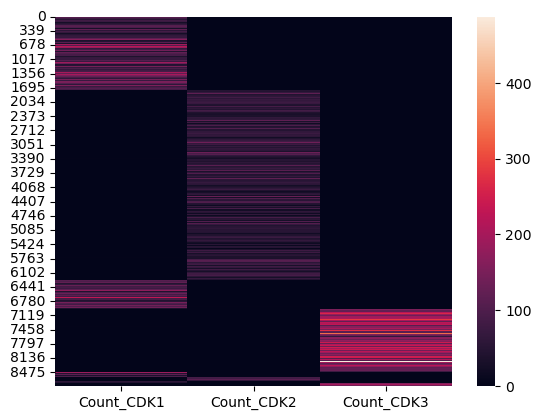

In [156]:
d3 = library2[library2['classification']!='non-targeting control'][['Count_CDK1', 'Count_CDK2', 'Count_CDK3']]
import seaborn as sns
sns.heatmap(d3)

In [267]:
targ = library2[library2['classification']!='non-targeting control']
pool1 = targ[targ['Pool']=='F1-R1']
pool2 = targ[targ['Pool']=='F2-R2']
pool3 = targ[targ['Pool']=='F3-R3']


print(pool1[['Count_BC_CDK1', 'Count_BC_CDK2', 'Count_BC_CDK3']].sum())
print(pool2[['Count_BC_CDK1', 'Count_BC_CDK2', 'Count_BC_CDK3']].sum())
print(pool3[['Count_BC_CDK1', 'Count_BC_CDK2', 'Count_BC_CDK3']].sum())

print(pool1[['Count_BC_CDK1', 'Count_BC_CDK2', 'Count_BC_CDK3']].max())
print(pool2[['Count_BC_CDK1', 'Count_BC_CDK2', 'Count_BC_CDK3']].max())
print(pool3[['Count_BC_CDK1', 'Count_BC_CDK2', 'Count_BC_CDK3']].max())

print(pool1[['Count_proto_CDK1', 'Count_proto_CDK2', 'Count_proto_CDK3']].max())
print(pool2[['Count_proto_CDK1', 'Count_proto_CDK2', 'Count_proto_CDK3']].max())
print(pool3[['Count_proto_CDK1', 'Count_proto_CDK2', 'Count_proto_CDK3']].max())

Count_BC_CDK1    237217
Count_BC_CDK2       188
Count_BC_CDK3       145
dtype: int64
Count_BC_CDK1       330
Count_BC_CDK2    269135
Count_BC_CDK3       223
dtype: int64
Count_BC_CDK1       254
Count_BC_CDK2       178
Count_BC_CDK3    268931
dtype: int64
Count_BC_CDK1    373
Count_BC_CDK2      3
Count_BC_CDK3      3
dtype: int64
Count_BC_CDK1      3
Count_BC_CDK2    233
Count_BC_CDK3      3
dtype: int64
Count_BC_CDK1      3
Count_BC_CDK2      3
Count_BC_CDK3    569
dtype: int64
Count_proto_CDK1    299
Count_proto_CDK2      3
Count_proto_CDK3      3
dtype: int64
Count_proto_CDK1      2
Count_proto_CDK2    190
Count_proto_CDK3     86
dtype: int64
Count_proto_CDK1      3
Count_proto_CDK2      2
Count_proto_CDK3    475
dtype: int64


In [169]:
pool2[pool2['Count_CDK3']==228]

,gRNA_id,proto_G+19,Pool,classification,Count_CDK1,Count_CDK2,Count_CDK3
8659,gRNA_CDK13_intron_8660,GCCCAAAGTGCTGGGATTAC,F2-R2,intron,0,85,228


In [168]:
library[library['proto_G+19']=='GCCCAAAGTGCTGGGATTAC']

,gRNA_id,Gene,protospacer,proto_G+19,chrom,exon,proto_start,proto_end,PAM,PAM_start,...,CDS_hit,ABE_amenable,CBE_amenable,classification,nearest_exon_distance,Pool,Hamming_BC,gRNA_oligo,RE_sites,gRNA_id_OLD
8659,gRNA_CDK13_intron_8660,CDK13,TCCCAAAGTGCTGGGATTAC,GCCCAAAGTGCTGGGATTAC,7.0,intron1_2,39961120.0,39961101.0,AG,39961099.0,...,NaN,NaN,NaN,intron,9249.0,F2-R2,TGCTGGATATCCC,GTGTAACCCGTAGGGCACCTAGCGTACACGTCTCACACCGCCCAAA...,2,NaN
8764,gRNA_CDK4_intron_8765,CDK4,TCCCAAAGTGCTGGGATTAC,GCCCAAAGTGCTGGGATTAC,12.0,intron1_2,57748962.0,57748981.0,AG,57748982.0,...,NaN,NaN,NaN,intron,201.0,F3-R3,TTGGGAACAATGG,CAGCGCCAATGGGCTTTCGAAGCGTACACGTCTCACACCGCCCAAA...,2,NaN


In [102]:
library2.loc[library2['proto_G+19']=='GCGGATGGCTCTGGACGTGA', 'Count_CDK2']+=1

In [103]:
library2

,gRNA_id,proto_G+19,Pool,Count_CDK2
0,gRNA_CDK7_targ_1,GCGGATGGCTCTGGACGTGA,F1-R1,1
1,gRNA_CDK7_targ_2,GGGCTCTGGACGTGAAGTCT,F1-R1,0
2,gRNA_CDK7_targ_3,GGCTCTGGACGTGAAGTCTC,F1-R1,0
3,gRNA_CDK7_targ_4,GCTCTGGACGTGAAGTCTCG,F1-R1,0
4,gRNA_CDK7_targ_5,GGACGTGAAGTCTCGGGCAA,F1-R1,0
...,...,...,...,...
9248,gRNA_nt_9249,GTCTGTCCTAATTCGGATCG,F3-R3,0
9249,gRNA_nt_9250,GGCGGCGTAATGCTTGAAAG,F3-R3,0
9250,gRNA_nt_9251,GCCGTGTTGCTGGATACGCC,F3-R3,0
9251,gRNA_nt_9252,GACCCTCCGGATACGGACTG,F3-R3,0


In [78]:
library = pd.read_csv('CDK_library_final.csv')
library

,gRNA_id,Gene,protospacer,proto_G+19,chrom,exon,proto_start,proto_end,PAM,PAM_start,...,CDS_hit,ABE_amenable,CBE_amenable,classification,nearest_exon_distance,Pool,Hamming_BC,gRNA_oligo,RE_sites,gRNA_id_OLD
0,gRNA_CDK7_targ_1,CDK7,CCGGATGGCTCTGGACGTGA,GCGGATGGCTCTGGACGTGA,5.0,1,69234972.0,69234991.0,AG,69234992.0,...,True,True,False,targeting,NaN,F1-R1,CACATACGCACTA,AGGCACTTGCTCGTACGACGAGCGTACACGTCTCACACCGCGGATG...,2,gRNA_1
1,gRNA_CDK7_targ_2,CDK7,TGGCTCTGGACGTGAAGTCT,GGGCTCTGGACGTGAAGTCT,5.0,1,69234977.0,69234996.0,CG,69234997.0,...,True,False,True,targeting,NaN,F1-R1,CCTATACCCGAAT,AGGCACTTGCTCGTACGACGAGCGTACACGTCTCACACCGGGCTCT...,2,gRNA_2
2,gRNA_CDK7_targ_3,CDK7,GGCTCTGGACGTGAAGTCTC,GGCTCTGGACGTGAAGTCTC,5.0,1,69234978.0,69234997.0,GG,69234998.0,...,True,False,True,targeting,NaN,F1-R1,TATACAATTCGCA,AGGCACTTGCTCGTACGACGAGCGTACACGTCTCACACCGGCTCTG...,2,gRNA_3
3,gRNA_CDK7_targ_4,CDK7,GCTCTGGACGTGAAGTCTCG,GCTCTGGACGTGAAGTCTCG,5.0,1,69234979.0,69234998.0,GG,69234999.0,...,True,True,True,targeting,NaN,F1-R1,CCGGAGTAGGTCC,AGGCACTTGCTCGTACGACGAGCGTACACGTCTCACACCGCTCTGG...,2,gRNA_4
4,gRNA_CDK7_targ_5,CDK7,GGACGTGAAGTCTCGGGCAA,GGACGTGAAGTCTCGGGCAA,5.0,1,69234984.0,69235003.0,AG,69235004.0,...,True,True,True,targeting,NaN,F1-R1,ATTGCAAGGGCCC,AGGCACTTGCTCGTACGACGAGCGTACACGTCTCACACCGGACGTG...,2,gRNA_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9248,gRNA_nt_9249,NaN,GATCTGTCCTAATTCGGATCG,GTCTGTCCTAATTCGGATCG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,non-targeting control,NaN,F3-R3,TAACTACGAGCTA,CAGCGCCAATGGGCTTTCGAAGCGTACACGTCTCACACCGTCTGTC...,2,NaN
9249,gRNA_nt_9250,NaN,GTGCGGCGTAATGCTTGAAAG,GGCGGCGTAATGCTTGAAAG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,non-targeting control,NaN,F3-R3,TGCAAGTTACCCA,CAGCGCCAATGGGCTTTCGAAGCGTACACGTCTCACACCGGCGGCG...,2,NaN
9250,gRNA_nt_9251,NaN,GGCCGTGTTGCTGGATACGCC,GCCGTGTTGCTGGATACGCC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,non-targeting control,NaN,F3-R3,TGATGCATGCACC,CAGCGCCAATGGGCTTTCGAAGCGTACACGTCTCACACCGCCGTGT...,2,NaN
9251,gRNA_nt_9252,NaN,GTACCCTCCGGATACGGACTG,GACCCTCCGGATACGGACTG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,non-targeting control,NaN,F3-R3,AACCGATGCCGGT,CAGCGCCAATGGGCTTTCGAAGCGTACACGTCTCACACCGACCCTC...,2,NaN


In [88]:
len('GTTCCTTTTCATTATCCAGAG')

21

In [73]:
count_no

29723

In [70]:
i

321836

In [74]:
forward

154909

In [75]:
reverse

137204